Preprocessing split: train_i


  0%|          | 0/285 [00:00<?, ?it/s]

Preprocessing split: val_i


  0%|          | 0/36 [00:00<?, ?it/s]

Preprocessing split: test_i


...

Balancing train_i: Adding 117 Malignant images...
Balancing test_i: Adding 18 Malignant images...
Balancing val_i: Adding 12 Malignant images...


Expanding train_i:   0%|          | 0/402 [00:00<?, ?it/s]

Expanding val_i:   0%|          | 0/48 [00:00<?, ?it/s]

Expanding test_i:   0%|          | 0/54 [00:00<?, ?it/s]

Expanding s_unlabelled_i: 0it [00:00, ?it/s]

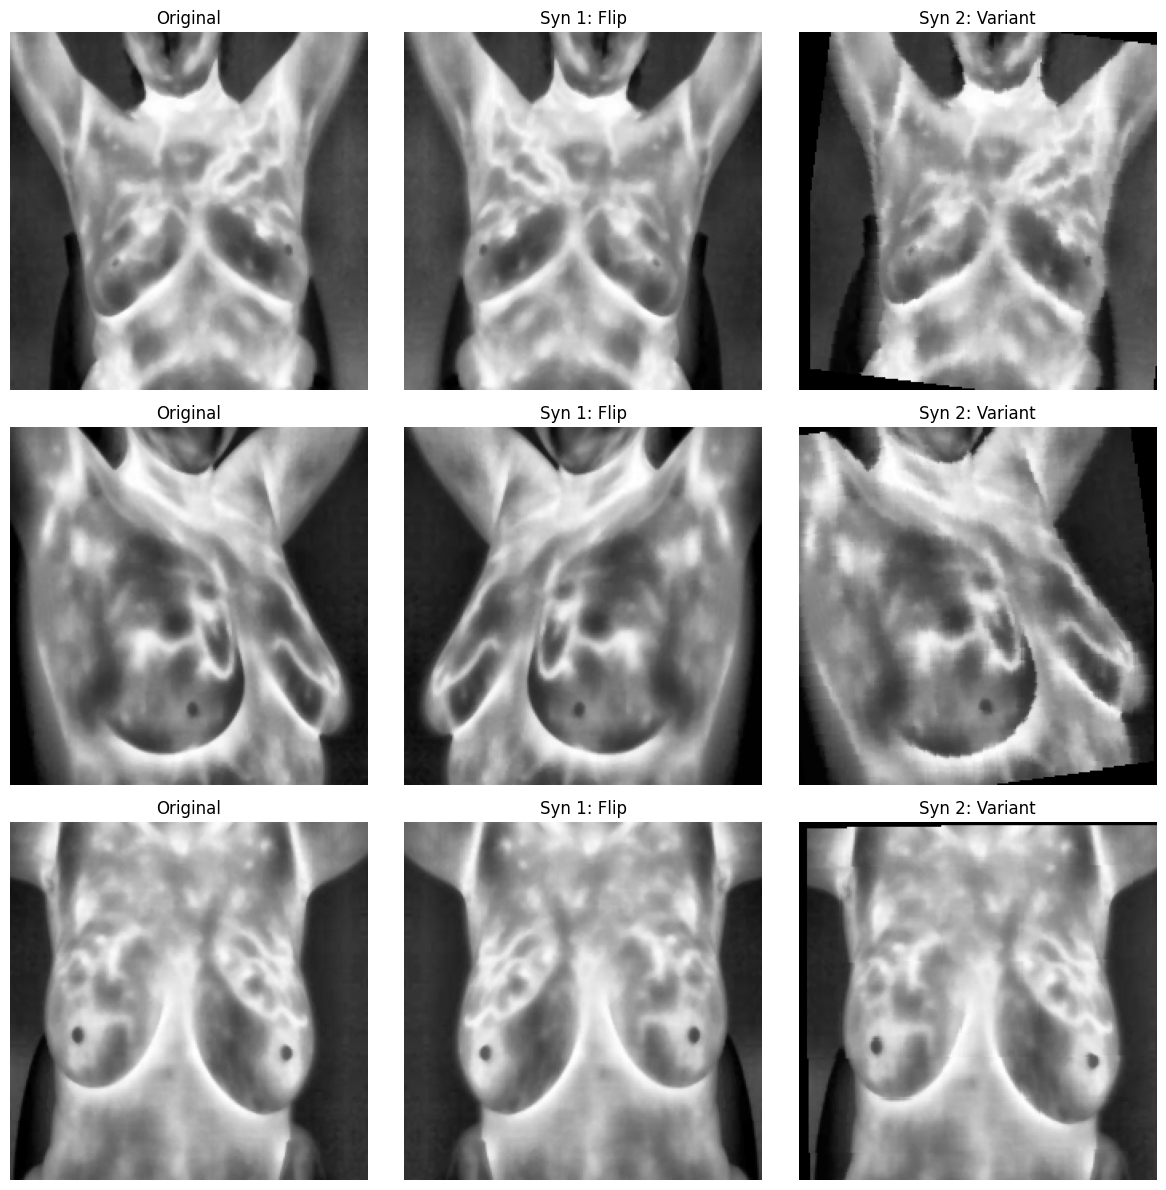


FINAL DATASET STATISTICS
Directory: train_i | Total Images: 1206
  --> [CLASS COUNT] Benign: 603
  --> [CLASS COUNT] Malignant: 603
Directory: val_i | Total Images: 144
Directory: test_i | Total Images: 162
Directory: s_unlabelled_i | Total Images: 0


In [1]:
import os
import cv2
import torch
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from torchvision import transforms

# --- 1. THERMAL PREPROCESSOR (Filtering & Resizing Only) ---
class ThermalPreprocessor:
    def __init__(self):
        # Standardize to 224x224
        self.resize_op = transforms.Resize((224, 224))

    def apply_filters(self, img_np):
        """
        ✅ FIX: Works entirely in grayscale — no fake RGB round-trips.
        Input : (H, W, 3) RGB numpy array or (H, W) grayscale array
        Output: (H, W) uint8 grayscale numpy array
        """
        # Ensure we work on a true grayscale array regardless of input mode
        if img_np.ndim == 3:
            gray = cv2.cvtColor(img_np.astype(np.uint8), cv2.COLOR_RGB2GRAY)
        else:
            gray = img_np.astype(np.uint8)

        # ✅ FIX: Kernel 3 instead of 5 — preserves fine thermal gradients
        denoised = cv2.medianBlur(gray, 3)

        # ✅ FIX: clipLimit 2.0 instead of 3.0 — avoids over-amplifying noise
        #         in uniform-temperature (healthy tissue) regions
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        enhanced = clahe.apply(denoised)

        # ✅ FIX: Return true grayscale array (H, W) — no conversion back to RGB
        return enhanced

    def process(self, pil_img):
        """
        Pipeline: Resize → Grayscale → Filter.
        ✅ FIX: Saves as mode "L" (single-channel) PIL — consistent with the
                1-channel training pipeline; eliminates the RGB→gray→RGB
                round-trip that happened at every training-time load.
        """
        resized = self.resize_op(pil_img.convert("RGB"))
        img_np  = np.array(resized)
        enhanced = self.apply_filters(img_np)
        return Image.fromarray(enhanced)        # mode "L" — true grayscale


# --- 2. AUGMENTATION ENGINE (Expansion) ---
def get_thermal_variant_aug():
    """
    Controlled transformations that preserve heat signatures.
    ✅ FIX: ColorJitter removed — thermography encodes temperature as pixel
            intensity, so randomly shifting brightness/contrast corrupts the
            physical signal the model is trying to learn.
    """
    return transforms.Compose([
        transforms.RandomRotation(degrees=10),
        transforms.RandomAffine(
            degrees=0,
            translate=(0.05, 0.05),
            scale=(0.95, 1.05)
        ),
    ])


def generate_synthetic_pair(pil_img):
    """Generates exactly 2 synthetic images per original."""
    # Syn 1: Pure Horizontal Flip
    syn1 = transforms.functional.hflip(pil_img)
    # Syn 2: Random Thermal-Preserving Variant
    syn2 = get_thermal_variant_aug()(pil_img)
    return syn1, syn2


# --- 3. ROS BALANCING UTILITY (Over-sampling) ---
def get_heavy_balancing_aug():
    """
    Heavy augmentation used to balance training classes.
    ✅ FIX: RandomVerticalFlip removed — vertical flips produce anatomically
            impossible orientations for breast thermography (breasts pointing
            downward), which can confuse the model with invalid patterns.
    ✅ FIX: ColorJitter removed — same reason as get_thermal_variant_aug.
    """
    return transforms.Compose([
        transforms.RandomAffine(
            degrees=15,
            translate=(0.1, 0.1),
            scale=(0.9, 1.1)
        ),
    ])


# --- 4. PREVIEW UTILITY ---
def preview_expansion(output_dir, num_samples=3):
    """
    Plots Triplets: Original, Syn1 (Flip), Syn2 (Variant).
    ✅ FIX: cmap="gray" added — images are now true grayscale (mode "L")
            so imshow needs cmap="gray" to render correctly.
    """
    all_files = [f for f in os.listdir(output_dir) if not f.startswith('syn')]
    samples   = np.random.choice(all_files, min(num_samples, len(all_files)))

    fig, axes = plt.subplots(len(samples), 3, figsize=(12, 4 * len(samples)))
    if len(samples) == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, base_f in enumerate(samples):
        orig   = Image.open(os.path.join(output_dir, base_f))
        s1_path = os.path.join(output_dir, f"syn1_flip_{base_f}")
        s2_path = os.path.join(output_dir, f"syn2_aug_{base_f}")

        # ✅ FIX: cmap="gray" for all panels
        axes[i, 0].imshow(orig, cmap="gray")
        axes[i, 0].set_title("Original")

        if os.path.exists(s1_path):
            axes[i, 1].imshow(Image.open(s1_path), cmap="gray")
            axes[i, 1].set_title("Syn 1: Flip")

        if os.path.exists(s2_path):
            axes[i, 2].imshow(Image.open(s2_path), cmap="gray")
            axes[i, 2].set_title("Syn 2: Variant")

        for ax in axes[i]:
            ax.axis('off')

    plt.tight_layout()
    plt.show()


# --- 5. MAIN PIPELINE ---
def run_full_thermal_pipeline(base_path, output_base="/kaggle/working/"):

    proc     = ThermalPreprocessor()
    raw_data = []

    # A. Discovery
    categories = ["Benign", "Malignant", "Unlabelled"]
    for cat in categories:
        cat_p = os.path.join(base_path, cat)
        if not os.path.exists(cat_p):
            continue
        for p_id in os.listdir(cat_p):
            p_dir = os.path.join(cat_p, p_id)
            if os.path.isdir(p_dir):
                for f in os.listdir(p_dir):
                    if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                        raw_data.append({
                            'p_id':  p_id,
                            'label': cat,
                            'path':  os.path.join(p_dir, f)
                        })

    df      = pd.DataFrame(raw_data)
    labeled = df[df['label'] != "Unlabelled"].reset_index(drop=True)

    # B. STRATIFIED PATIENT-AWARE SPLIT
    patient_meta            = labeled.groupby('p_id')['label'].first().reset_index()
    patient_meta['label_idx'] = patient_meta['label'].map({'Benign': 0, 'Malignant': 1})

    tr_p, temp_p, tr_l, temp_l = train_test_split(
        patient_meta['p_id'], patient_meta['label_idx'],
        test_size=0.2, stratify=patient_meta['label_idx'], random_state=42
    )
    val_p, test_p = train_test_split(
        temp_p, test_size=0.5, stratify=temp_l, random_state=42
    )

    splits = {
        'train_i':       labeled[labeled['p_id'].isin(tr_p)],
        'val_i':         labeled[labeled['p_id'].isin(val_p)],
        'test_i':        labeled[labeled['p_id'].isin(test_p)],
        's_unlabelled_i': df[df['label'] == "Unlabelled"]
    }

    # C. PREPROCESS AND SAVE ORIGINALS
    for folder, d_frame in splits.items():
        out_dir = os.path.join(output_base, folder)
        os.makedirs(out_dir, exist_ok=True)
        print(f"Preprocessing split: {folder}")
        for _, row in tqdm(d_frame.iterrows(), total=len(d_frame)):
            processed  = proc.process(Image.open(row['path']))
            # ✅ Save as PNG — lossless, correct for grayscale single-channel
            base_fname = (
                f"{row['label']}_{row['p_id']}_"
                f"{os.path.splitext(os.path.basename(row['path']))[0]}.png"
            )
            processed.save(os.path.join(out_dir, base_fname))

    # D. CLASS BALANCING (ROS on train_i)
    target_train = os.path.join(output_base, 'train_i')
    benign_f     = [f for f in os.listdir(target_train) if 'Benign'    in f]
    malignant_f  = [f for f in os.listdir(target_train) if 'Malignant' in f]
    diff         = len(benign_f) - len(malignant_f)

    if diff > 0:
        print(f"Balancing train_i: Adding {diff} Malignant images...")
        bal_aug = get_heavy_balancing_aug()
        for i in range(diff):
            src_path = os.path.join(target_train, np.random.choice(malignant_f))
            src_img  = Image.open(src_path)
            # ✅ FIX: Save as PNG (lossless) instead of JPEG — JPEG compression
            #         introduces artifacts on synthetic data being augmented
            bal_aug(src_img).save(
                os.path.join(target_train, f"Malignant_Balanced_{i}.png")
            )

    # D1. CLASS BALANCING (ROS on train_i)
    target_test = os.path.join(output_base, 'test_i')
    benign_f     = [f for f in os.listdir(target_test) if 'Benign'    in f]
    malignant_f  = [f for f in os.listdir(target_test) if 'Malignant' in f]
    diff         = len(benign_f) - len(malignant_f)

    if diff > 0:
        print(f"Balancing test_i: Adding {diff} Malignant images...")
        bal_aug = get_heavy_balancing_aug()
        for i in range(diff):
            src_path = os.path.join(target_test, np.random.choice(malignant_f))
            src_img  = Image.open(src_path)
            # ✅ FIX: Save as PNG (lossless) instead of JPEG — JPEG compression
            #         introduces artifacts on synthetic data being augmented
            bal_aug(src_img).save(
                os.path.join(target_test, f"Malignant_Balanced_{i}.png")
            )



    # D2. CLASS BALANCING (ROS on train_i)
    target_val = os.path.join(output_base, 'val_i')
    benign_f     = [f for f in os.listdir(target_val) if 'Benign'    in f]
    malignant_f  = [f for f in os.listdir(target_val) if 'Malignant' in f]
    diff         = len(benign_f) - len(malignant_f)

    if diff > 0:
        print(f"Balancing val_i: Adding {diff} Malignant images...")
        bal_aug = get_heavy_balancing_aug()
        for i in range(diff):
            src_path = os.path.join(target_val, np.random.choice(malignant_f))
            src_img  = Image.open(src_path)
            # ✅ FIX: Save as PNG (lossless) instead of JPEG — JPEG compression
            #         introduces artifacts on synthetic data being augmented
            bal_aug(src_img).save(
                os.path.join(target_val, f"Malignant_Balanced_{i}.png")
            )

    # E. EXPANSION (2 Syn images per every image in every folder)
    for folder in splits.keys():
        out_dir        = os.path.join(output_base, folder)
        existing_files = [f for f in os.listdir(out_dir) if not f.startswith('syn')]
        for f_name in tqdm(existing_files, desc=f"Expanding {folder}"):
            img      = Image.open(os.path.join(out_dir, f_name))
            s1, s2   = generate_synthetic_pair(img)
            # ✅ Preserve PNG extension for synthetic images too
            stem     = os.path.splitext(f_name)[0]
            s1.save(os.path.join(out_dir, f"syn1_flip_{stem}.png"))
            s2.save(os.path.join(out_dir, f"syn2_aug_{stem}.png"))

    # F. PREVIEW & ZIP
    preview_expansion(target_train)
    shutil.make_archive('/kaggle/working/expanded_thermal_dataset', 'zip', output_base)

    # G. FINAL STATISTICS AND CLASS COUNTS FOR TRAIN_I
    print("\n" + "=" * 40)
    print("FINAL DATASET STATISTICS")
    print("=" * 40)
    for folder in splits.keys():
        folder_path = os.path.join(output_base, folder)
        all_imgs    = os.listdir(folder_path)
        print(f"Directory: {folder} | Total Images: {len(all_imgs)}")
        if folder == 'train_i':
            b_cnt = len([f for f in all_imgs if 'Benign'    in f])
            m_cnt = len([f for f in all_imgs if 'Malignant' in f])
            print(f"  --> [CLASS COUNT] Benign: {b_cnt}")
            print(f"  --> [CLASS COUNT] Malignant: {m_cnt}")
    print("=" * 40)


# --- EXECUTION ---
dataset_path = '/kaggle/input/datasets/lilyofthevalley6666/breast-thermography-patients/Breast Therm/Breast Thermography/Breast Thermography'
run_full_thermal_pipeline(dataset_path)